In [13]:
"""
 Visualizations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

In [ ]:

# ============================================================================
# CONFIGURATION
# ============================================================================

# File paths
ABEBOOKS_PATH = 'data/processed/abebooks_cleaned.csv'
AMAZON_PATH = 'data/processed/amazon_cleaned.csv'


# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
COLORS = {'AbeBooks': '#2E86AB', 'Amazon': '#A23B72', 'abebooks': '#2E86AB'}

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

# ============================================================================
# LOAD DATA
# ============================================================================

print("=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)
print("\nLoading data...")

# Load data
abebooks_df = pd.read_csv(ABEBOOKS_PATH)
amazon_df = pd.read_csv(AMAZON_PATH)
df = pd.concat([abebooks_df, amazon_df], ignore_index=True)

# Normalize source names
df['source_clean'] = df['source'].apply(
    lambda x: 'Amazon' if 'Amazon' in x else 'AbeBooks'
)

print(f"✓ Loaded {len(df)} records")
print("\nGenerating visualizations...")
print("-" * 80)


GENERATING VISUALIZATIONS

Loading data...
✓ Loaded 294 records

Generating visualizations...
--------------------------------------------------------------------------------


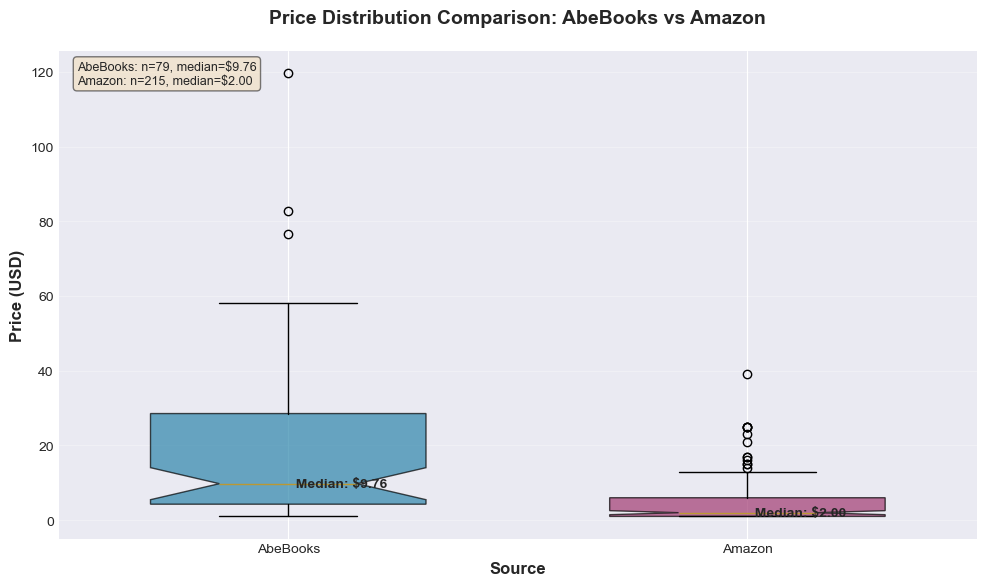

In [27]:

# ============================================================================
# VISUALIZATION 1: BOXPLOT BY SOURCE
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot
box_data = [
    df[df['source_clean'] == 'AbeBooks']['total_price'],
    df[df['source_clean'] == 'Amazon']['total_price']
]

bp = ax.boxplot(box_data, 
                labels=['AbeBooks', 'Amazon'],
                patch_artist=True,
                notch=True,
                widths=0.6)

# Color boxes
colors_list = [COLORS['AbeBooks'], COLORS['Amazon']]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Styling
ax.set_ylabel('Price (USD)', fontweight='bold')
ax.set_xlabel('Source', fontweight='bold')
ax.set_title('Price Distribution Comparison: AbeBooks vs Amazon', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Add median values as text
medians = [np.median(data) for data in box_data]
for i, median in enumerate(medians):
    ax.text(i+1, median, f'  Median: ${median:.2f}', 
            va='center', fontweight='bold', fontsize=10)

# Add statistics box
stats_text = f"AbeBooks: n={len(box_data[0])}, median=${np.median(box_data[0]):.2f}\n"
stats_text += f"Amazon: n={len(box_data[1])}, median=${np.median(box_data[1]):.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

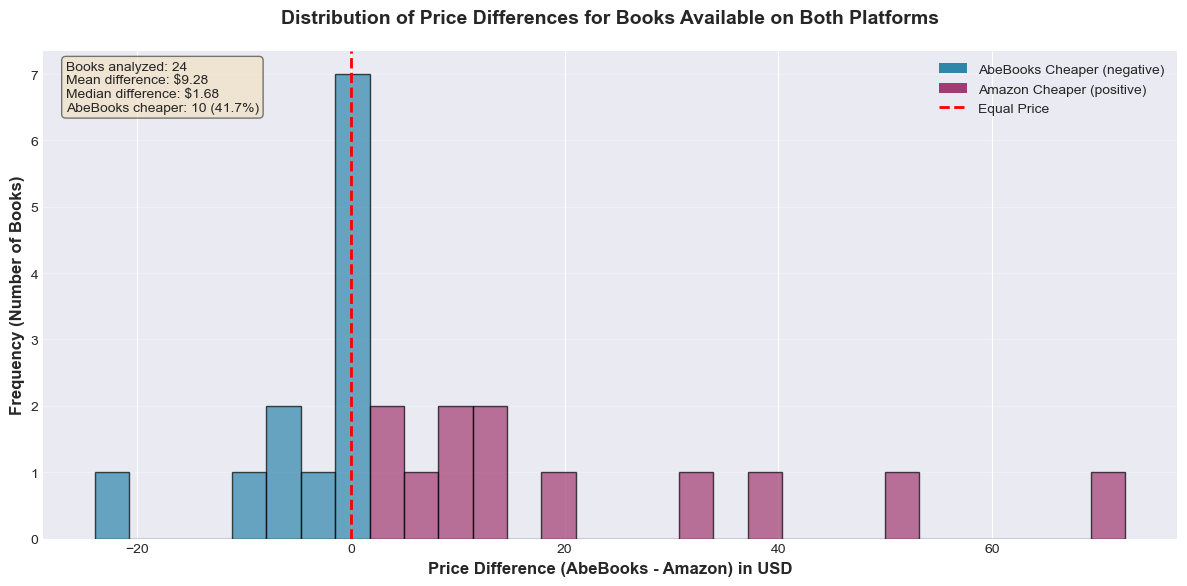

In [26]:


# ============================================================================
# VISUALIZATION 2: HISTOGRAM PRICE DIFFERENCE
# ============================================================================

# Get shared ISBNs
isbn_counts = df.groupby('isbn')['source_clean'].nunique()
shared_isbns = isbn_counts[isbn_counts > 1].index.tolist()
shared_df = df[df['isbn'].isin(shared_isbns)].copy()

# Get minimum price per ISBN per source
price_comparison = shared_df.groupby(['isbn', 'source_clean'])['total_price'].min().unstack(fill_value=np.nan)
price_comparison = price_comparison.dropna()
price_comparison['price_diff'] = price_comparison['AbeBooks'] - price_comparison['Amazon']

# Create histogram
fig, ax = plt.subplots(figsize=(12, 6))

n, bins, patches = ax.hist(price_comparison['price_diff'], 
                            bins=30, 
                            edgecolor='black', 
                            alpha=0.7)

# Color bars based on positive/negative
for i, patch in enumerate(patches):
    if bins[i] < 0:
        patch.set_facecolor(COLORS['AbeBooks'])
    else:
        patch.set_facecolor(COLORS['Amazon'])

# Add vertical line at zero
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Equal Price')

# Styling
ax.set_xlabel('Price Difference (AbeBooks - Amazon) in USD', fontweight='bold')
ax.set_ylabel('Frequency (Number of Books)', fontweight='bold')
ax.set_title('Distribution of Price Differences for Books Available on Both Platforms', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['AbeBooks'], label='AbeBooks Cheaper (negative)'),
    Patch(facecolor=COLORS['Amazon'], label='Amazon Cheaper (positive)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Equal Price')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add statistics
mean_diff = price_comparison['price_diff'].mean()
median_diff = price_comparison['price_diff'].median()
abebooks_cheaper = (price_comparison['price_diff'] < 0).sum()
pct_cheaper = (abebooks_cheaper / len(price_comparison)) * 100

stats_text = f"Books analyzed: {len(price_comparison)}\n"
stats_text += f"Mean difference: ${mean_diff:.2f}\n"
stats_text += f"Median difference: ${median_diff:.2f}\n"
stats_text += f"AbeBooks cheaper: {abebooks_cheaper} ({pct_cheaper:.1f}%)"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5), fontsize=10)

plt.tight_layout()
plt.show()


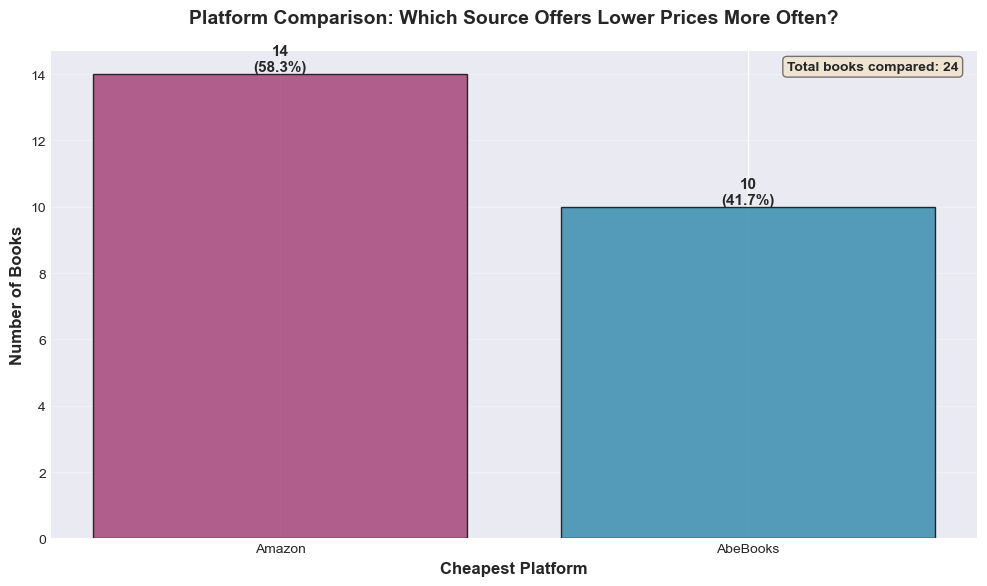

In [25]:

# ============================================================================
# VISUALIZATION 3: WINNER BAR CHART
# ============================================================================

# Determine winner for each ISBN
def determine_winner(row):
    if abs(row['price_diff']) < 0.01:
        return 'Tie'
    elif row['price_diff'] < 0:
        return 'AbeBooks'
    else:
        return 'Amazon'

price_comparison['winner'] = price_comparison.apply(determine_winner, axis=1)
winner_counts = price_comparison['winner'].value_counts()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'AbeBooks': COLORS['AbeBooks'], 
              'Amazon': COLORS['Amazon'], 
              'Tie': '#95B8D1'}

bars = ax.bar(winner_counts.index, winner_counts.values, 
               color=[colors_map.get(x, '#95B8D1') for x in winner_counts.index],
               edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    pct = (height / len(price_comparison)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Styling
ax.set_ylabel('Number of Books', fontweight='bold')
ax.set_xlabel('Cheapest Platform', fontweight='bold')
ax.set_title('Platform Comparison: Which Source Offers Lower Prices More Often?', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Add total
ax.text(0.98, 0.98, f'Total books compared: {len(price_comparison)}', 
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

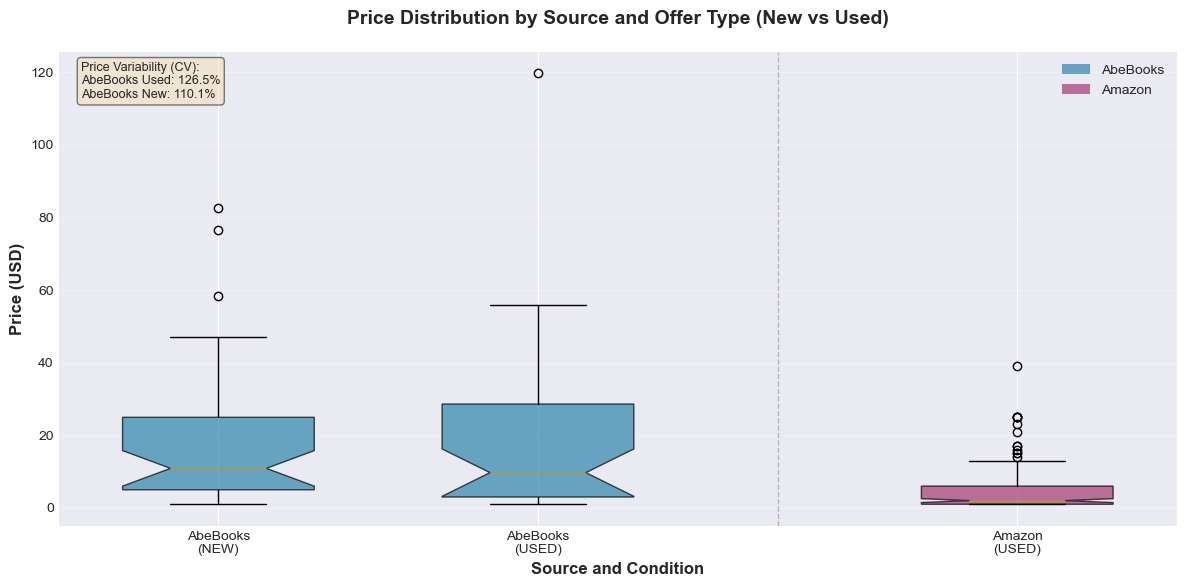

In [24]:

# ============================================================================
# VISUALIZATION 4: GROUPED BOXPLOT OFFER TYPE
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
data_to_plot = []
labels = []
colors_list = []
positions = []

pos = 1
for source in ['AbeBooks', 'Amazon']:
    for offer_type in ['new', 'used']:
        subset = df[(df['source_clean'] == source) & (df['offer_type'] == offer_type)]
        if len(subset) > 0:
            data_to_plot.append(subset['total_price'])
            labels.append(f"{source}\n({offer_type.upper()})")
            colors_list.append(COLORS[source])
            positions.append(pos)
            pos += 1
    pos += 0.5

# Create boxplot
bp = ax.boxplot(data_to_plot, 
                positions=positions,
                labels=labels,
                patch_artist=True,
                notch=True,
                widths=0.6)

# Color boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Styling
ax.set_ylabel('Price (USD)', fontweight='bold')
ax.set_xlabel('Source and Condition', fontweight='bold')
ax.set_title('Price Distribution by Source and Offer Type (New vs Used)', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

# Add vertical separator
ax.axvline(x=2.75, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Add legend
legend_elements = [
    Patch(facecolor=COLORS['AbeBooks'], alpha=0.7, label='AbeBooks'),
    Patch(facecolor=COLORS['Amazon'], alpha=0.7, label='Amazon')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add statistics box
used_cv_abe = df[(df['source_clean'] == 'AbeBooks') & (df['offer_type'] == 'used')]['total_price'].std() / \
              df[(df['source_clean'] == 'AbeBooks') & (df['offer_type'] == 'used')]['total_price'].mean() * 100
new_cv_abe = df[(df['source_clean'] == 'AbeBooks') & (df['offer_type'] == 'new')]['total_price'].std() / \
             df[(df['source_clean'] == 'AbeBooks') & (df['offer_type'] == 'new')]['total_price'].mean() * 100

stats_text = f"Price Variability (CV):\n"
stats_text += f"AbeBooks Used: {used_cv_abe:.1f}%\n"
stats_text += f"AbeBooks New: {new_cv_abe:.1f}%"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.show()

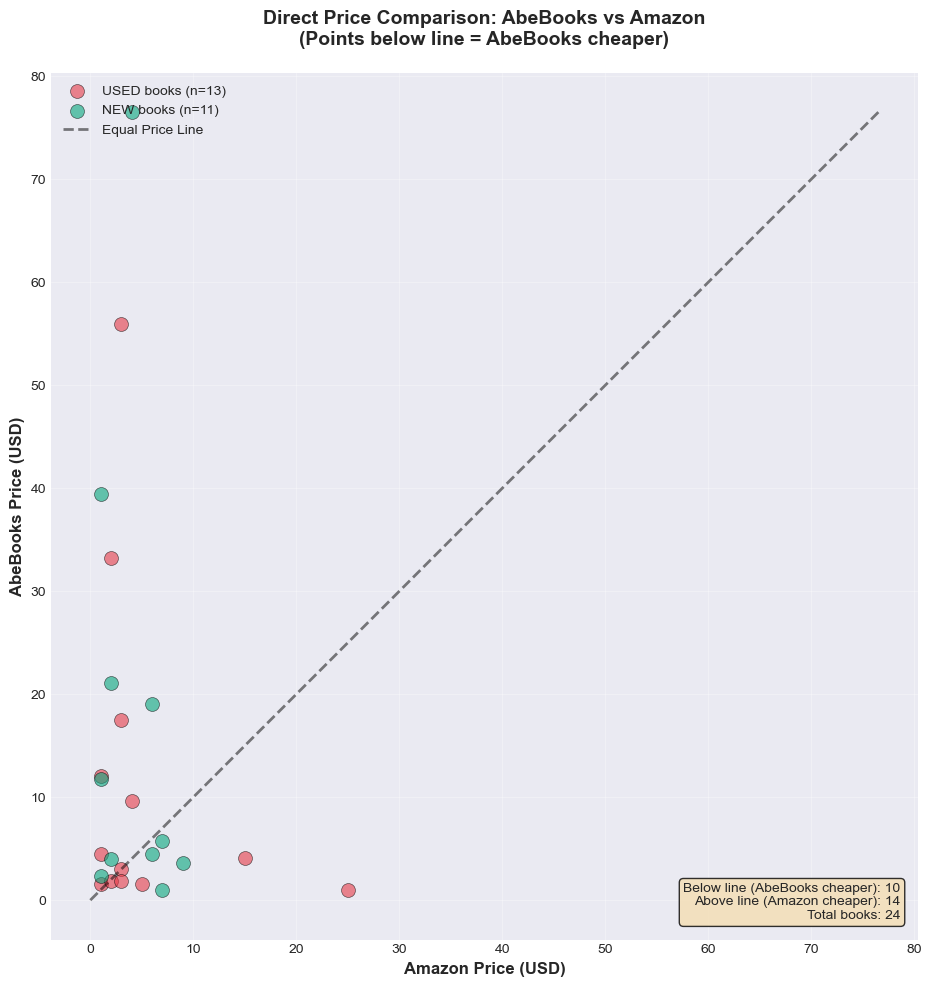

In [23]:

# ============================================================================
# VISUALIZATION 5: SCATTER DIRECT COMPARISON
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Get offer type for coloring
shared_isbns = price_comparison.index.tolist()
shared_df_viz = df[df['isbn'].isin(shared_isbns)].copy()
isbn_offer_type = shared_df_viz.groupby('isbn')['offer_type'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'used')
price_comparison['offer_type'] = price_comparison.index.map(isbn_offer_type)

# Create scatter plot
for offer_type, color in [('used', '#E63946'), ('new', '#06A77D')]:
    subset = price_comparison[price_comparison['offer_type'] == offer_type]
    ax.scatter(subset['Amazon'], subset['AbeBooks'], 
              alpha=0.6, s=100, c=color, 
              label=f'{offer_type.upper()} books (n={len(subset)})',
              edgecolors='black', linewidth=0.5)

# Add diagonal reference line
max_price = max(price_comparison['Amazon'].max(), price_comparison['AbeBooks'].max())
ax.plot([0, max_price], [0, max_price], 'k--', linewidth=2, alpha=0.5, label='Equal Price Line')

# Styling
ax.set_xlabel('Amazon Price (USD)', fontweight='bold', fontsize=12)
ax.set_ylabel('AbeBooks Price (USD)', fontweight='bold', fontsize=12)
ax.set_title('Direct Price Comparison: AbeBooks vs Amazon\n(Points below line = AbeBooks cheaper)', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.9)

# Add annotations
below_line = (price_comparison['AbeBooks'] < price_comparison['Amazon']).sum()
above_line = (price_comparison['AbeBooks'] > price_comparison['Amazon']).sum()

stats_text = f"Below line (AbeBooks cheaper): {below_line}\n"
stats_text += f"Above line (Amazon cheaper): {above_line}\n"
stats_text += f"Total books: {len(price_comparison)}"

ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


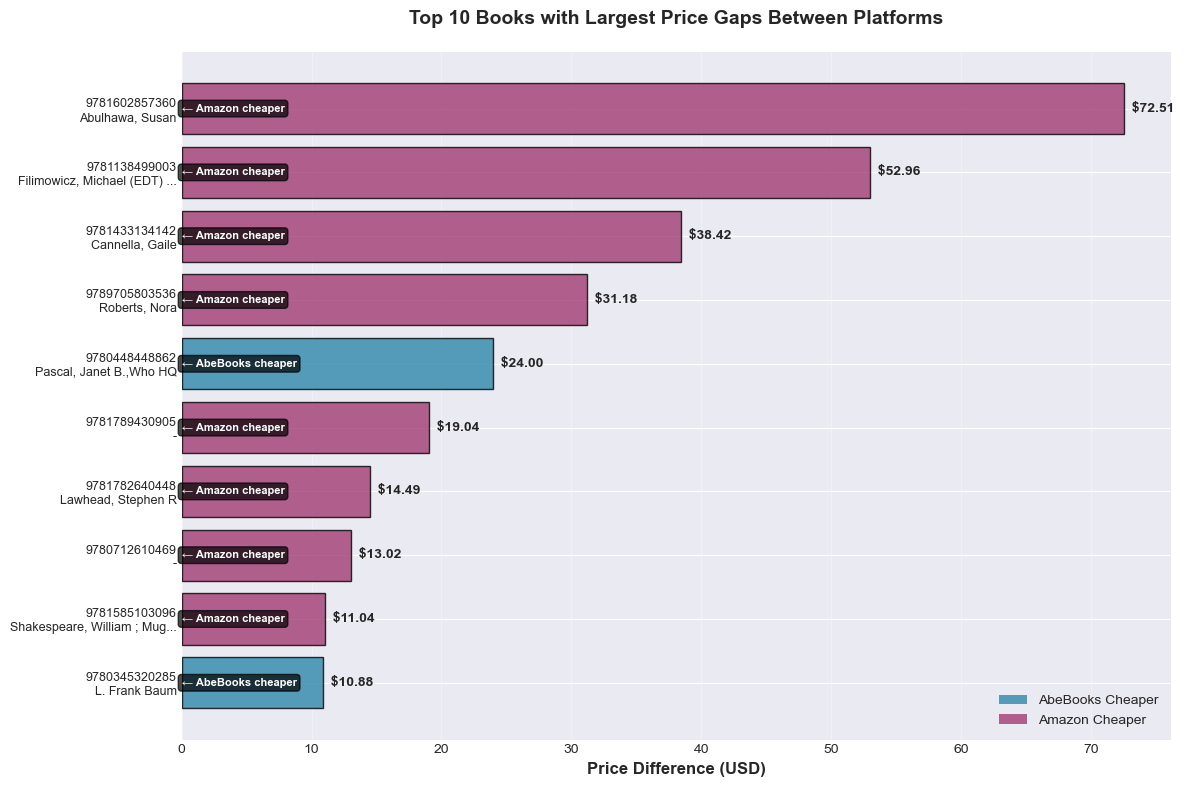

In [22]:

# ============================================================================
# VISUALIZATION 6: TOP 10 PRICE GAPS
# ============================================================================

# Get top 10 largest absolute differences
price_comparison['abs_diff'] = price_comparison['price_diff'].abs()
top10 = price_comparison.nlargest(10, 'abs_diff').copy()

# Determine winner
top10['winner'] = top10.apply(lambda row: 'AbeBooks' if row['price_diff'] < 0 else 'Amazon', axis=1)

# Get book info
isbn_info = df.groupby('isbn').agg({'author': 'first'}).to_dict()['author']
top10['author'] = top10.index.map(lambda x: isbn_info.get(x, 'Unknown')[:30])
top10['label'] = [f"{isbn}\n{author}" for isbn, author in zip(top10.index, top10['author'])]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Sort by absolute difference
top10_sorted = top10.sort_values('abs_diff', ascending=True)

colors_list = [COLORS['AbeBooks'] if w == 'AbeBooks' else COLORS['Amazon'] 
               for w in top10_sorted['winner']]

bars = ax.barh(range(len(top10_sorted)), top10_sorted['abs_diff'], 
               color=colors_list, edgecolor='black', alpha=0.8)

# Add value labels
for i, (bar, row) in enumerate(zip(bars, top10_sorted.iterrows())):
    width = bar.get_width()
    isbn, data = row
    ax.text(width, i, f'  ${width:.2f}', 
            va='center', fontweight='bold', fontsize=10)
    
    # Add winner indicator
    winner_text = f"← {data['winner']} cheaper"
    ax.text(0, i, winner_text, va='center', ha='left', 
            fontsize=8, color='white', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Set labels
ax.set_yticks(range(len(top10_sorted)))
ax.set_yticklabels([label[:40] + '...' if len(label) > 40 else label 
                    for label in top10_sorted['label']], fontsize=9)
ax.set_xlabel('Price Difference (USD)', fontweight='bold')
ax.set_title('Top 10 Books with Largest Price Gaps Between Platforms', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

# Add legend
legend_elements = [
    Patch(facecolor=COLORS['AbeBooks'], alpha=0.8, label='AbeBooks Cheaper'),
    Patch(facecolor=COLORS['Amazon'], alpha=0.8, label='Amazon Cheaper')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()
